<a href="https://colab.research.google.com/github/kkbin505/MEng_classify_fashion_MNIST/blob/DenseNet/DenseNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import

In [126]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Set seed for reproducibility
seed_value = 33
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


Load the Data

In [127]:
# Load Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize images and add channel dimension
train_images = train_images[..., np.newaxis] / 255.0
test_images = test_images[..., np.newaxis] / 255.0

# One-hot encode labels
num_classes = 10
train_labels_onehot = tf.keras.utils.to_categorical(train_labels, num_classes)
test_labels_onehot = tf.keras.utils.to_categorical(test_labels, num_classes)

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Train images shape:", train_images.shape)
print("Test images shape:", test_images.shape)

Train images shape: (60000, 28, 28, 1)
Test images shape: (10000, 28, 28, 1)


# Making the Capsule Network

In [130]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

# Input shape
input_shape = (28, 28, 1)  # grayscale images
num_classes = 10

# Since DenseNet expects 3 channels, we will replicate the single channel 3 times
inputs = layers.Input(shape=input_shape)
x = layers.Concatenate()([inputs, inputs, inputs])  # convert 1 channel -> 3 channels

# Resize the input to 32x32 before feeding into DenseNet using tf.image.resize
x = layers.Lambda(lambda image: tf.image.resize(image, (32, 32)))(x)

# Load DenseNet121 without the top classification layer
base_model = DenseNet121(
    include_top=False,
    weights=None,   # start with random weights
    input_shape=(32, 32, 3),
    pooling='avg'   # global average pooling at the end
)

x = base_model(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_42      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 28, 28, 3) │          0 │ input_layer_42[0… │
│ (Concatenate)       │                   │            │ input_layer_42[0… │
│                     │                   │            │ input_layer_42[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32, 32, 3) │          0 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 1024)      │  7,037,504 │ lambda[0][0]      │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │     10,250 │ densenet121[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,047,754 (26.89 MB)

 Trainable params: 6,964,106 (26.57 MB)

 Non-trainable params: 83,648 (326.75 KB)

**Compiling Model**

In [131]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

**Training Model**

In [132]:
history = model.fit(train_images, train_labels_onehot,
                    epochs=10,
                    batch_size=64,
                    validation_data=(test_images, test_labels_onehot))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1264s 1s/step - accuracy: 0.7819 - loss: 0.6107 - val_accuracy: 0.8546 - val_loss: 0.4008
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1244s 1s/step - accuracy: 0.8790 - loss: 0.3239 - val_accuracy: 0.8791 - val_loss: 0.3284
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1175s 1s/step - accuracy: 0.8973 - loss: 0.2771 - val_accuracy: 0.8812 - val_loss: 0.3269
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1194s 1s/step - accuracy: 0.9073 - loss: 0.2482 - val_accuracy: 0.8852 - val_loss: 0.3289
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1176s 1s/step - accuracy: 0.9143 - loss: 0.2274 - val_accuracy: 0.8823 - val_loss: 0.3554
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1199s 1s/step - accuracy: 0.9214 - loss: 0.2071 - val_accuracy: 0.8873 - val_loss: 0.3487
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1190s 1s/step - accuracy: 0.9298 - loss: 0.1858 - val_accuracy: 0.8778 - val_loss: 0.4304
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1188s 1s/step - accuracy: 0.9362 - loss: 0.1711 - 

**Helper Functions**

In [133]:
# Helper functions to visualize the predictions
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])  # remove x-axis ticks
    plt.yticks([])  # remove y-axis ticks
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})",
               color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))  # Show all the 10 class labels
    plt.yticks([])  # remove y-axis ticks
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])  # Set y-axis to range between 0 and 1
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')  # highlight the predicted class
    thisplot[true_label].set_color('blue')  # highlight the true class


**Evaluate the Model**

In [134]:
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels_onehot, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')


Evaluating model on test data...
313/313 - 42s - 134ms/step - accuracy: 0.8809 - loss: 0.4427

Test accuracy: 0.8809


**Make Predictions**

In [135]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 165ms/step


**Visualize a Prediction**


Visualizing a prediction...


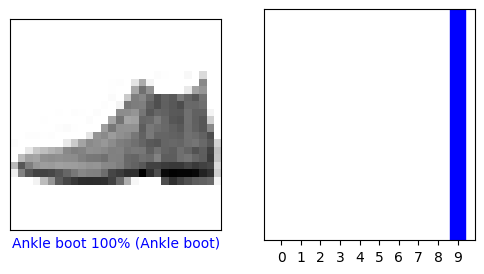

In [136]:
# Visualizing a prediction
print("\nVisualizing a prediction...")
i = 0  # You can change this to any index for different images
plt.figure(figsize=(6,3))

# Plot the image and prediction
plt.subplot(1, 2, 1)
plot_image(i, predictions[i], test_labels, test_images)

# Plot the value array (prediction probabilities for each class)
plt.subplot(1, 2, 2)
plot_value_array(i, predictions[i], test_labels)

plt.show()

**Plot Training Data**


Plotting training history...


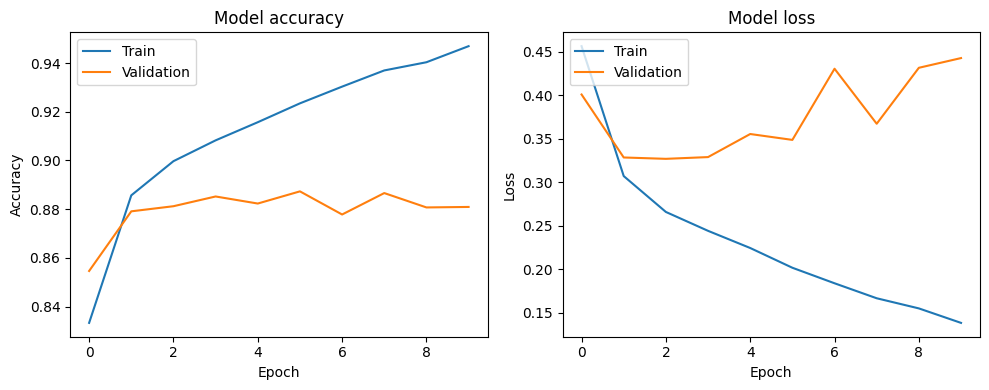

In [137]:
# Plot training & validation accuracy values
print("\nPlotting training history...")
plt.figure(figsize=(10, 4))

# Training vs validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Training vs validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()
